# MA(q) Parameter Estimation

The moving average model of order $q$, denoted by $\text{MA}(q)$, is defined by,

$
\begin{align}
X_t = \sum_{i=1}^q \vartheta_i \varepsilon_{t-i} + \varepsilon_t
\end{align}
\tag{1}
$

where $\varepsilon_t$ are independent and identically distributed random variables with distribution,

$
\begin{align}
\varepsilon_i \sim \text{Normal}(0, \sigma)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
&\text{E}[\varepsilon_t] = 0 \\
&\text{E}[\varepsilon_t^2] = \sigma^2 \\
&\text{E}[\varepsilon_t \varepsilon_s] = \delta_{ts} \sigma^2
\end{align}
\tag{3}
$

Here the $\vartheta_i$ are estimated given an $MA(q)$ time series. 

## Includes

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def comparison_plot(θ_vals, title, ylim, *params):
    labels = [f"θ={val}" for val in θ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ma_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6), lw=1)
    return t, scan

## Simulations ($\sigma = 1$)

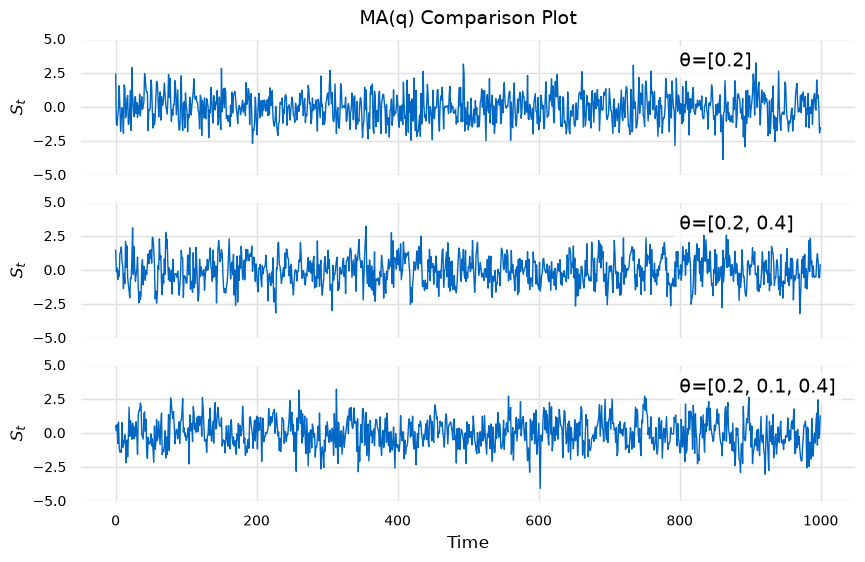

In [3]:
nsample = 1000
σ = 1.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-5.0, 5.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [4]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1461.292
Date:                Sun, 30 Aug 2026   AIC                           2928.584
Time:                        11:23:08   BIC                           2943.308
Sample:                             0   HQIC                          2934.180
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0474      0.040     -1.192      0.233      -0.125       0.031
ma.L1          0.2029      0.031      6.553      0.000       0.142       0.264
sigma2         1.0883      0.049     22.226      0.000       0.992       1.184
===================================================================================
Ljung-Box (L1) (Q):                   0.06   Jarque-Bera (JB):                 2.01
Prob(Q):                              0.80   Prob(JB):                         0.37
Heteroskedasticity (H):               1.17   Skew:                             0.11
Prob(H) (two-sided):                  0.15   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [5]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "trend": "c",
   "const": {
      "est": -0.04740345594803671,
      "err": 0.03977405160509189,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "605f3016-ccf0-4b93-aeaa-4e6c28ebfdfe",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.2028727870644204,
         "err": 0.030959188954171886,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "605f3016-ccf0-4b93-aeaa-4e6c28ebfdfe",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 1.0883419121079398,
      "err": 0.04896775461224276,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [6]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1408.129
Date:                Sun, 30 Aug 2026   AIC                           2824.258
Time:                        11:23:08   BIC                           2843.889
Sample:                             0   HQIC                          2831.719
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0049      0.049     -0.100      0.921      -0.101       0.091
ma.L1          0.1994      0.030      6.700      0.000       0.141       0.258
ma.L2          0.3638      0.030     12.267      0.000       0.306       0.422
sigma2         0.9783      0.045     21.772      0.000       0.890       1.066
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 0.41
Prob(Q):                              0.84   Prob(JB):                         0.81
Heteroskedasticity (H):               1.00   Skew:                            -0.01
Prob(H) (two-sided):                  0.98   Kurtosis:                         2.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "trend": "c",
   "const": {
      "est": -0.004877934168453942,
      "err": 0.048925385609542,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "2b2f0588-6bcf-4865-b1bc-d9a9fe8cb227",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.19942570438371585,
         "err": 0.029766262429648013,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "2b2f0588-6bcf-4865-b1bc-d9a9fe8cb227",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.36375287280587454,
         "err": 0.029653961792882773,
         "est_label": "$\\hat{\\theta_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{2}}}$",
         "row": 0,
         "column": 0,
         "or

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [8]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -1402.583
Date:                Sun, 30 Aug 2026   AIC                           2815.166
Time:                        11:23:08   BIC                           2839.705
Sample:                             0   HQIC                          2824.493
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0107      0.054      0.200      0.842      -0.094       0.116
ma.L1          0.2356      0.029      8.020      0.000       0.178       0.293
ma.L2          0.1186      0.030      3.943      0.000       0.060       0.178
ma.L3          0.3618      0.031     11.758      0.000       0.301       0.422
sigma2         0.9673      0.045     21.631      0.000       0.880       1.055
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.80
Prob(Q):                              0.96   Prob(JB):                         0.25
Heteroskedasticity (H):               1.13   Skew:                            -0.12
Prob(H) (two-sided):                  0.27   Kurtosis:                         2.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "trend": "c",
   "const": {
      "est": 0.010693175098990848,
      "err": 0.05359956341063947,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "38090859-917f-4c30-a69a-65752f59d40f",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.2356353908581527,
         "err": 0.029379773710812244,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "38090859-917f-4c30-a69a-65752f59d40f",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.1186228450789392,
         "err": 0.030082338194802997,
         "est_label": "$\\hat{\\theta_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{2}}}$",
         "row": 0,
         "column": 0,
         "ord

## Simulations ($\sigma = 5$)

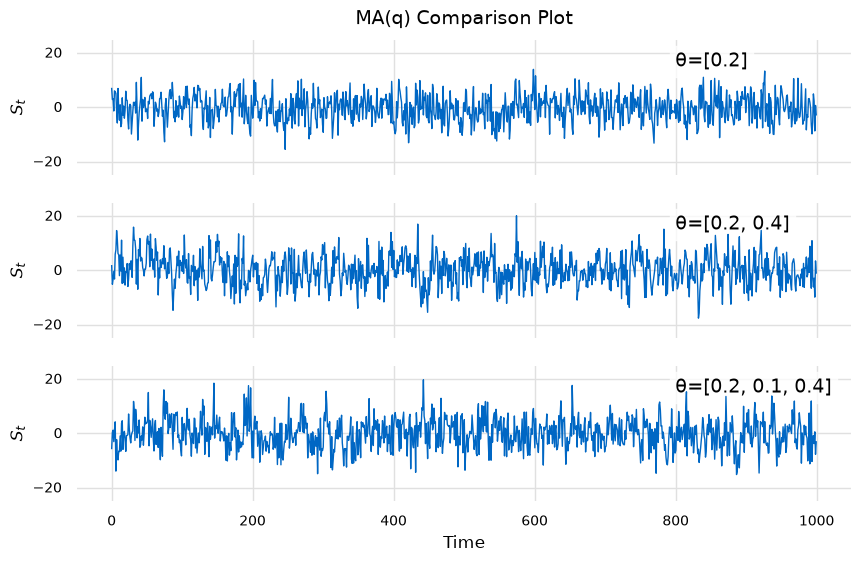

In [10]:
nsample = 1000
σ = 5.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-25.0, 25.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [11]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -2979.614
Date:                Sun, 30 Aug 2026   AIC                           5965.228
Time:                        11:23:08   BIC                           5979.952
Sample:                             0   HQIC                          5970.824
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3377      0.182     -1.853      0.064      -0.695       0.019
ma.L1          0.2093      0.032      6.559      0.000       0.147       0.272
sigma2        22.6757      1.087     20.854      0.000      20.545      24.807
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 2.96
Prob(Q):                              0.96   Prob(JB):                         0.23
Heteroskedasticity (H):               1.00   Skew:                            -0.04
Prob(H) (two-sided):                  0.99   Kurtosis:                         2.74
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "trend": "c",
   "const": {
      "est": -0.3376650014941383,
      "err": 0.18219475911343683,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "f929a599-92c2-4999-957f-2031229b73af",
      "param_type": "ARMA_CONST"
   },
   "order": 1,
   "params": [
      {
         "est": 0.20931587687356862,
         "err": 0.03191202603364337,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "f929a599-92c2-4999-957f-2031229b73af",
         "param_type": "ARMA_PARAM"
      }
   ],
   "sigma2": {
      "est": 22.675709397023184,
      "err": 1.0873583223867567,
      "est_label": "$\\hat{\\sigma^2}$",
      "err_label": "$\\sigma_{\\hat{\\sigma^2}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "e

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [13]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -3036.731
Date:                Sun, 30 Aug 2026   AIC                           6081.462
Time:                        11:23:08   BIC                           6101.093
Sample:                             0   HQIC                          6088.923
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0808      0.264      0.306      0.759      -0.436       0.598
ma.L1          0.1793      0.027      6.663      0.000       0.127       0.232
ma.L2          0.4730      0.027     17.489      0.000       0.420       0.526
sigma2        25.4076      1.164     21.829      0.000      23.126      27.689
===================================================================================
Ljung-Box (L1) (Q):                   0.43   Jarque-Bera (JB):                 0.41
Prob(Q):                              0.51   Prob(JB):                         0.82
Heteroskedasticity (H):               0.90   Skew:                             0.03
Prob(H) (two-sided):                  0.33   Kurtosis:                         2.92
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "trend": "c",
   "const": {
      "est": 0.08077435514562079,
      "err": 0.2638322144984862,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "80dc44a3-9c15-43e4-a20d-591fea58d18c",
      "param_type": "ARMA_CONST"
   },
   "order": 2,
   "params": [
      {
         "est": 0.17930327492770906,
         "err": 0.026911036121859164,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "80dc44a3-9c15-43e4-a20d-591fea58d18c",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.473045676130441,
         "err": 0.027047973709991496,
         "est_label": "$\\hat{\\theta_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{2}}}$",
         "row": 0,
         "column": 0,
         "order

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [15]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -3056.621
Date:                Sun, 30 Aug 2026   AIC                           6123.242
Time:                        11:23:08   BIC                           6147.780
Sample:                             0   HQIC                          6132.568
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0837      0.267     -0.314      0.753      -0.606       0.439
ma.L1          0.1615      0.030      5.331      0.000       0.102       0.221
ma.L2          0.0928      0.032      2.940      0.003       0.031       0.155
ma.L3          0.3790      0.031     12.336      0.000       0.319       0.439
sigma2        26.4402      1.136     23.277      0.000      24.214      28.666
===================================================================================
Ljung-Box (L1) (Q):                   0.48   Jarque-Bera (JB):                 2.18
Prob(Q):                              0.49   Prob(JB):                         0.34
Heteroskedasticity (H):               0.90   Skew:                             0.04
Prob(H) (two-sided):                  0.35   Kurtosis:                         3.21
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
print(result_model.to_json(pretty=True))

{
   "est_model": "ARMA",
   "arma_est_type": "MA",
   "trend": "c",
   "const": {
      "est": -0.08369600003080392,
      "err": 0.26650504854037416,
      "est_label": "$\\hat{\\mu}$",
      "err_label": "$\\sigma_{\\hat{\\mu}}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "fde956ea-1d95-455b-b0cc-eba08cf10a36",
      "param_type": "ARMA_CONST"
   },
   "order": 3,
   "params": [
      {
         "est": 0.16153941524679918,
         "err": 0.03030240977167475,
         "est_label": "$\\hat{\\theta_{1}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{1}}}$",
         "row": 0,
         "column": 0,
         "order": 1,
         "est_id": "fde956ea-1d95-455b-b0cc-eba08cf10a36",
         "param_type": "ARMA_PARAM"
      },
      {
         "est": 0.09277015826331317,
         "err": 0.03155391633411936,
         "est_label": "$\\hat{\\theta_{2}}$",
         "err_label": "$\\sigma_{\\hat{\\theta_{2}}}$",
         "row": 0,
         "column": 0,
         "ord